In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.ipynb" --to python
!jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.ipynb" --to python

[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.ipynb to python
[NbConvertApp] Writing 5544 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.py
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.ipynb to python
[NbConvertApp] Writing 4470 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.py


In [2]:
import sys, os

py_file_location = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/"
sys.path.append(os.path.abspath(py_file_location))

import importlib, dataset, modules
importlib.reload(dataset)
importlib.reload(modules)

from dataset import *
from modules import *

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/AD_NC/train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/AD_NC/test"

train_ds, val_ds, test_ds = create_datasets(train_dir, test_dir)
train_loader, val_loader, test_loader = create_dataloaders(train_ds, val_ds, test_ds)

Using device: cuda


In [5]:
def run_epoch(model, loader, criterion=None, optimizer=None, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    loop = tqdm(loader, desc="Training" if train else "Validation", leave=True)
    for data, targets in loop:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        loss = criterion(outputs, targets)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        _, preds = outputs.max(1)
        total += targets.size(0)
        correct += preds.eq(targets).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

        acc = 100 * correct / total
        loop.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{acc:.2f}%")

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, accuracy, f1

In [6]:
'''
model = ConvNeXt(in_chans=1, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

num_epochs = 2
train_losses, val_losses = [], []
train_accuracies, val_accuracies, val_f1s = [], [], []
best_val_acc = 0.0
'''

model = ConvNeXt(in_chans=1, num_classes=2).to(device)

label_smoothing = 0.1
class_weights = count_classes(train_ds)
learning_rate = 3e-4
weight_decay = 1e-4
num_epochs = 2
num_warmup_epochs = 1

train_losses, val_losses = [], []
train_accuracies, val_accuracies, val_f1s = [], [], []
best_val_acc = 0.0
patience = 100
epochs_without_improvement = 0
early_stop = False

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=torch.tensor(class_weights, dtype=torch.float32, device=device))

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=num_warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - num_warmup_epochs), eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[num_warmup_epochs])

save_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/multi file solution/"


Dataset class distribution:
  AD: 8320
  NC: 8880
  Total: 17200


In [15]:
print("🚀 Starting ConvNeXt training...\n")

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    print("-" * 40)

    train_loss, train_acc, _ = run_epoch(model, train_loader, criterion=criterion, optimizer=optimizer, train=True)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion=criterion, optimizer=None, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_f1s.append(val_f1)

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs(save_dir, exist_ok=True)
        torch.save(model.state_dict(), os.path.join(save_dir, "best_convnext_adni.pth"))
        print(f"✅ New best model saved (Val Acc = {best_val_acc:.2f}%)")
        epochs_no_improve = 0  # reset counter
    else:
      epochs_without_improvement += 1
      print(f"⚠️ No improvement for {epochs_without_improvement} epoch(s).")

      if epochs_without_improvement >= patience:
          print(f"⏹️ Early stopping triggered after {epoch} epochs!")
          early_stop = True
          break

print("\n🎉 Training complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

🚀 Starting ConvNeXt training...


Epoch 1/2
----------------------------------------


Validation: 100%|██████████| 34/34 [00:07<00:00,  4.59it/s, Acc=59.51%, Loss=0.7408]


Train Loss: 0.6451 | Train Acc: 63.47%
Val   Loss: 0.6581 | Val Acc:   59.51% | F1: 0.5435
✅ New best model saved (Val Acc = 59.51%)

Epoch 2/2
----------------------------------------


Validation: 100%|██████████| 34/34 [00:07<00:00,  4.42it/s, Acc=59.70%, Loss=0.7501]


Train Loss: 0.6385 | Train Acc: 64.75%
Val   Loss: 0.6509 | Val Acc:   59.70% | F1: 0.5469
✅ New best model saved (Val Acc = 59.70%)

🎉 Training complete!
Best Validation Accuracy: 59.70%


In [21]:
def plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies, val_f1s):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, "r-", label="Train Loss")
    plt.plot(epochs, val_losses, "g-", label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, "r-", label="Train Accuracy")
    plt.plot(epochs, val_accuracies, "g-", label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_f1s, "-b", label="Validation F1 Score")
    plt.title("Validation F1 Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

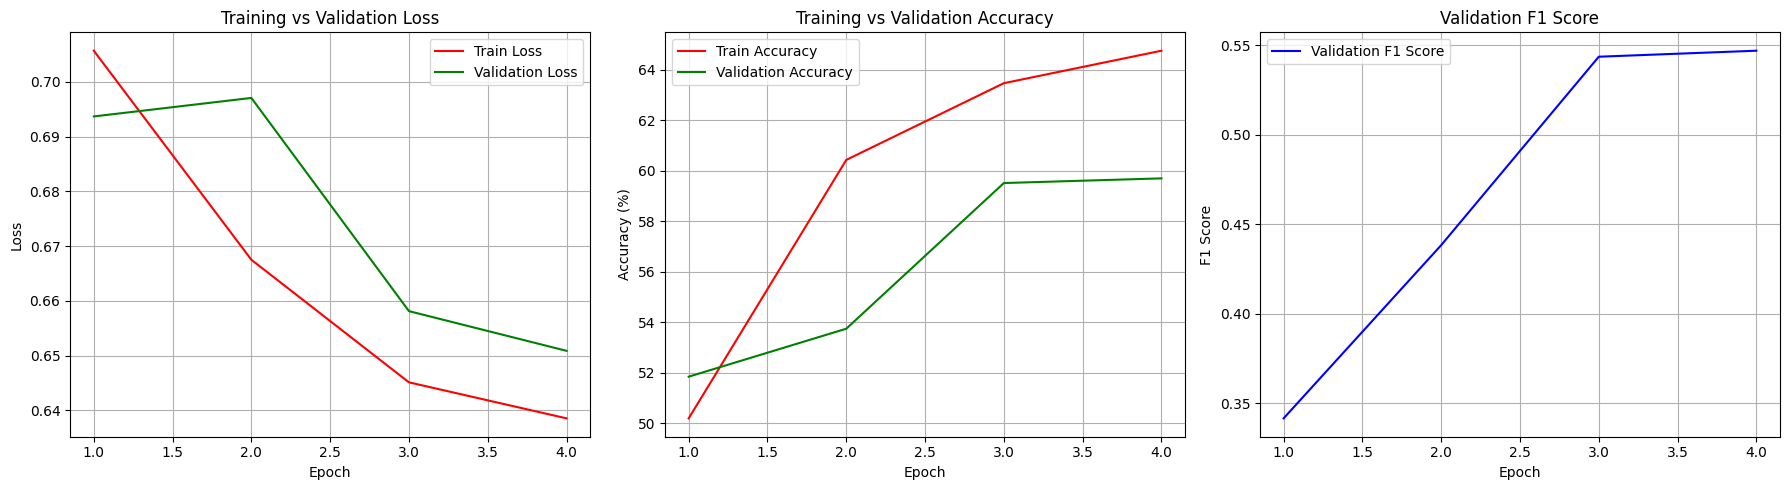

In [22]:
plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies, val_f1s)

In [23]:
def evaluate_model(model, test_loader):
    model.eval()

    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for data, targets in tqdm(test_loader, desc="Testing", leave=True):
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Compute metrics
    accuracy = (np.array(all_preds) == np.array(all_targets)).mean() * 100

    return accuracy, all_preds, all_targets, all_probs

In [24]:
print("\n📊 Evaluating best model on test set...")
model.load_state_dict(torch.load("best_convnext_adni.pth", map_location=device))

accuracy, all_preds, all_targets, all_probs = evaluate_model(model, test_loader)

print(f"\n✅ Test Accuracy: {accuracy:.4f}%")
print("\n📋 Classification Report:")
print(classification_report(all_targets, all_preds, target_names=["AD", "NC"], digits=4))


📊 Evaluating best model on test set...


Testing:  23%|██▎       | 16/71 [00:04<00:15,  3.52it/s]


KeyboardInterrupt: 

In [11]:
def plot_confusion_matrix(all_targets, all_preds):
    cm = confusion_matrix(all_targets, all_preds)
    cm_norm = confusion_matrix(all_targets, all_preds, normalize="true")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay(cm, display_labels=["AD", "NC"]).plot(ax=ax[0], cmap="Reds", colorbar=False)
    ax[0].set_title("Confusion Matrix (Raw)")

    ConfusionMatrixDisplay(cm_norm, display_labels=["AD", "NC"]).plot(ax=ax[1], cmap="Greens", colorbar=True)
    ax[1].set_title("Normalized Confusion Matrix")

    plt.tight_layout()
    plt.show()

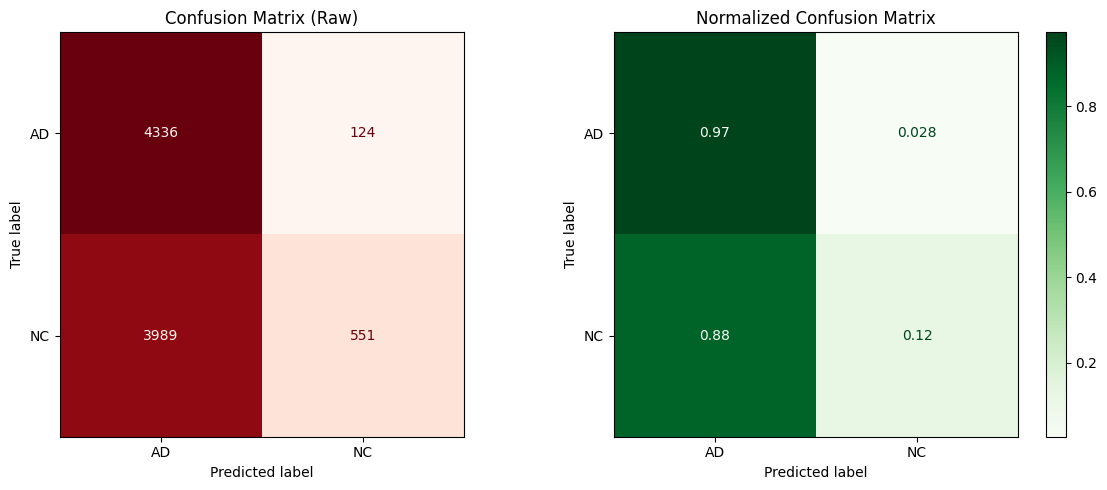

In [12]:
plot_confusion_matrix(all_targets, all_preds)